In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv(
    "../data/train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "Title", "Genre", "Description"]
)

train.head()

,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [3]:
train.shape

(54214, 4)

In [4]:
train.isnull().sum()

ID             0
Title          0
Genre          0
Description    0
dtype: int64

In [5]:
train["Genre"].nunique()

27

In [6]:
train["Genre"].value_counts().head(10)

Genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64

In [7]:
train["Description_Length"] = train["Description"].apply(len)

train["Description_Length"].describe()

count    54214.000000
mean       599.452429
std        446.026620
min         41.000000
25%        324.000000
50%        463.000000
75%        712.000000
max      10503.000000
Name: Description_Length, dtype: float64

In [10]:
import matplotlib.pyplot as plt

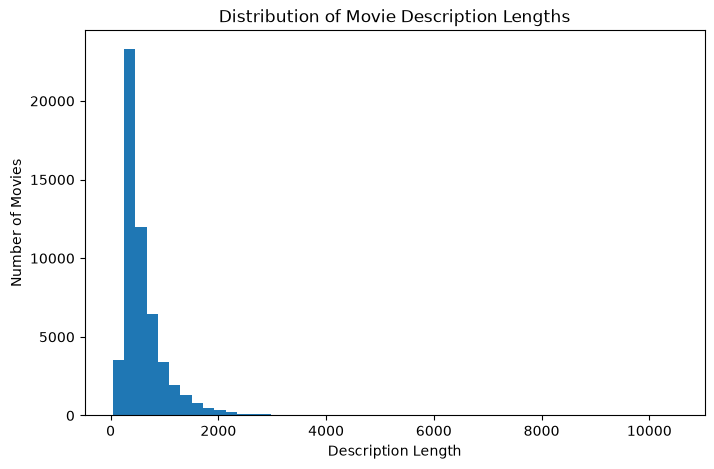

In [9]:
plt.figure(figsize=(8,5))
plt.hist(train["Description_Length"], bins=50)
plt.xlabel("Description Length")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Description Lengths")
plt.show()

In [11]:
train["Description"].sample(5, random_state=42)

5089     Catherine St.John-Burke is an independent, upt...
30323    Beginning of the century. In a train, a young ...
6415     Jerranium 90, a "little rock" that made all th...
20919    Deadly Tales II is an anthology of three horro...
29549    Grammy - music award of the American academy o...
Name: Description, dtype: str

In [12]:
from collections import Counter

In [13]:
all_words = " ".join(train["Description"]).lower().split()

word_counts = Counter(all_words)

word_counts.most_common(20)

[('the', 330861),
 ('and', 188957),
 ('a', 175045),
 ('of', 166866),
 ('to', 158306),
 ('in', 107683),
 ('is', 81596),
 ('his', 67476),
 ('with', 52129),
 ('her', 43421),
 ('he', 42525),
 ('for', 41243),
 ('that', 39960),
 ('on', 36037),
 ('as', 35067),
 ('their', 32340),
 ('by', 30571),
 ('an', 29321),
 ('from', 28798),
 ('who', 27615)]

In [14]:
X = train["Description"]
y = train["Genre"]

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(43371,)
(10843,)
(43371,)
(10843,)


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
vectorizer = TfidfVectorizer()

In [20]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [21]:
X_val_tfidf = vectorizer.transform(X_val)

In [22]:
print(X_train_tfidf.shape)
print(X_val_tfidf.shape)

(43371, 107481)
(10843, 107481)


In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [25]:
y_pred = model.predict(X_val_tfidf)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

In [27]:
print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.5837867748778014


In [28]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

      action       0.55      0.22      0.31       263
       adult       0.75      0.28      0.41       118
   adventure       0.70      0.10      0.18       155
   animation       0.33      0.01      0.02       100
   biography       0.00      0.00      0.00        53
      comedy       0.54      0.60      0.57      1490
       crime       0.50      0.01      0.02       101
 documentary       0.64      0.88      0.74      2619
       drama       0.55      0.80      0.65      2723
      family       0.57      0.05      0.09       157
     fantasy       0.00      0.00      0.00        65
   game-show       0.93      0.33      0.49        39
     history       0.00      0.00      0.00        49
      horror       0.68      0.55      0.60       441
       music       0.64      0.32      0.43       146
     musical       0.00      0.00      0.00        55
     mystery       0.00      0.00      0.00        64
        news       0.00    

/Users/lavanyasmacbookair/Documents/ML/Codsoft/task1/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lavanyasmacbookair/Documents/ML/Codsoft/task1/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lavanyasmacbookair/Documents/ML/Codsoft/task1/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

In [29]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['00' '000' '0000' '000th' '007' '00am' '00pm' '00s' '01' '012' '017' '02'
 '03' '0370' '04' '05' '0597' '05am' '06' '060']


In [30]:
print(model.coef_.shape)

(27, 107481)


In [31]:
print(model.classes_)

['action' 'adult' 'adventure' 'animation' 'biography' 'comedy' 'crime'
 'documentary' 'drama' 'family' 'fantasy' 'game-show' 'history' 'horror'
 'music' 'musical' 'mystery' 'news' 'reality-tv' 'romance' 'sci-fi'
 'short' 'sport' 'talk-show' 'thriller' 'war' 'western']


In [32]:
def top_words_for_genre(model, feature_names, genre, top_n=10):
    index = list(model.classes_).index(genre)

    top_indices = np.argsort(model.coef_[index])[-top_n:]

    return feature_names[top_indices[::-1]]

In [33]:
top_words_for_genre(model, feature_names, "horror")

array(['horror', 'evil', 'vampire', 'blood', 'house', 'dead', 'night',
       'killer', 'dark', 'terror'], dtype=object)

In [34]:
top_words_for_genre(model, feature_names, "western")

array(['ranch', 'gang', 'sheriff', 'outlaw', 'cattle', 'town', 'indians',
       'gold', 'outlaws', 'west'], dtype=object)

In [35]:
genres = ["drama", "comedy", "documentary", "horror", "western"]

for genre in genres:
    print(f"\n{genre.upper()}")
    print(top_words_for_genre(model, feature_names, genre))


DRAMA
['drama' 'lives' 'story' 'life' 'relationship' 'friendship' 'young'
 'based' 'son' 'mother']

COMEDY
['comedy' 'hilarious' 'comedic' 'funny' 'mockumentary' 'job' 'sitcom'
 'decides' 'sketches' 'eccentric']

DOCUMENTARY
['documentary' 'years' 'interviews' 'portrait' 'filmmaker' 'journey'
 'follows' 'of' 'film' 'documents']

HORROR
['horror' 'evil' 'vampire' 'blood' 'house' 'dead' 'night' 'killer' 'dark'
 'terror']

WESTERN
['ranch' 'gang' 'sheriff' 'outlaw' 'cattle' 'town' 'indians' 'gold'
 'outlaws' 'west']


In [36]:
vectorizer_improved = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [37]:
X_train_tfidf_improved = vectorizer_improved.fit_transform(X_train)
X_val_tfidf_improved = vectorizer_improved.transform(X_val)

In [38]:
lr_improved = LogisticRegression(max_iter=1000)

lr_improved.fit(X_train_tfidf_improved, y_train)

y_pred_improved = lr_improved.predict(X_val_tfidf_improved)

print("Improved LR Accuracy:", accuracy_score(y_val, y_pred_improved))

Improved LR Accuracy: 0.5714285714285714


In [39]:
from sklearn.svm import LinearSVC

In [40]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf_improved, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [41]:
svm_pred = svm_model.predict(X_val_tfidf_improved)

In [42]:
svm_accuracy = accuracy_score(y_val, svm_pred)

print("LinearSVC Accuracy:", svm_accuracy)

LinearSVC Accuracy: 0.5931015401641612


In [44]:
test = pd.read_csv(
    "../data/test_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "Title", "Description"]
)

In [45]:
X_test = vectorizer_improved.transform(test["Description"])

In [46]:
test_predictions = svm_model.predict(X_test)

In [47]:
test["Predicted_Genre"] = test_predictions

In [48]:
test[["ID", "Predicted_Genre"]].to_csv(
    "../data/predictions.csv",
    index=False
)

print("Predictions saved successfully🤓")

Predictions saved successfully🤓


In [49]:
import joblib

In [50]:
joblib.dump(svm_model, "../genre_classifier.pkl")
joblib.dump(vectorizer_improved, "../tfidf_vectorizer.pkl")

print("Model and vectorizer saved👍🏻")

Model and vectorizer saved👍🏻


In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Improved Logistic Regression",
        "Improved LinearSVC"
    ],
    "Accuracy": [
        0.5838,
        0.5714,
        0.5931
    ]
})

comparison

,Model,Accuracy
0,Baseline Logistic Regression,0.5838
1,Improved Logistic Regression,0.5714
2,Improved LinearSVC,0.5931
